# Dataset Preflight Proposal for Professor Fang

**Date:** 2026-06-30

**Purpose:** metadata-only proposal for choosing the first paired RNA/ATAC dataset to preflight.

Dear Professor Fang, I prepared this short notebook to summarize three public paired RNA/ATAC options and explain which dataset I would preflight first. I have kept this at the proposal stage: I did not download full matrices, train a model, or claim any biological result.

**Datasets compared:**

1. Down syndrome fetal cortex 10x Multiome
2. Focal cortical dysplasia type II 10x Multiome
3. Developing human neocortex snMultiome reference

**Review note:** tables and graph outputs are embedded in this notebook, so review does not require running code.

## Purpose and MOM Alignment

I am using this notebook to ask for guidance before starting any disease-specific implementation. I compare two developmental-disease paired RNA/ATAC candidates and one healthy developmental reference using public metadata from CELLxGENE and linked official records.

I tried to keep this aligned with the current MOM guidance:

- keep paired RNA/ATAC as the main requirement;
- prioritize human neurological, psychiatric, or developmental disease relevance;
- preserve donor-held-out evaluation before feature selection, tuning, or inference;
- treat healthy developmental datasets as references unless you approve a scope change;
- avoid result claims, novelty claims, or biological interpretation before file-level preflight.

My main question is whether you agree that I should run file-level preflight first on the Down syndrome fetal cortex dataset, or whether I should redirect to FCD II or another dataset you prefer.

In [1]:
from html import escape

try:
    from IPython.display import HTML, display
except Exception:
    HTML = None
    def display(value):
        print(value)

def show_html(html):
    if HTML is None:
        print(html)
    else:
        display(HTML(html))

def html_table(rows, columns):
    head = ''.join(f'<th>{escape(label)}</th>' for _, label in columns)
    body = []
    for row in rows:
        cells = ''.join(f'<td>{escape(str(row.get(key, "")))}</td>' for key, _ in columns)
        body.append(f'<tr>{cells}</tr>')
    return '<table><thead><tr>' + head + '</tr></thead><tbody>' + ''.join(body) + '</tbody></table>'

def bar_svg(labels, values, title, color, value_suffix=''):
    width, height = 900, 340
    left, bottom, top = 95, 70, 45
    chart_w = width - left - 40
    chart_h = height - top - bottom
    max_value = max(values) or 1
    gap = chart_w / len(values)
    bar_w = gap * 0.52
    svg = [f'<svg viewBox="0 0 {width} {height}" width="100%" role="img">']
    svg.append(f'<text x="{width/2}" y="24" text-anchor="middle" font-size="18" font-weight="600">{escape(title)}</text>')
    svg.append(f'<line x1="{left}" y1="{top}" x2="{left}" y2="{height-bottom}" stroke="#333"/>')
    svg.append(f'<line x1="{left}" y1="{height-bottom}" x2="{width-25}" y2="{height-bottom}" stroke="#333"/>')
    for i, (label, value) in enumerate(zip(labels, values)):
        x = left + i * gap + gap * 0.24
        h = chart_h * value / max_value
        y = height - bottom - h
        if isinstance(value, float):
            value_text = f'{value:.1f}{value_suffix}'
        else:
            value_text = f'{value:,}{value_suffix}'
        svg.append(f'<rect x="{x:.1f}" y="{y:.1f}" width="{bar_w:.1f}" height="{h:.1f}" fill="{color}"/>')
        svg.append(f'<text x="{x + bar_w/2:.1f}" y="{max(38, y-6):.1f}" text-anchor="middle" font-size="12">{value_text}</text>')
        svg.append(f'<text x="{x + bar_w/2:.1f}" y="{height-35}" text-anchor="middle" font-size="12">{escape(label)}</text>')
    svg.append('</svg>')
    show_html(''.join(svg))

datasets = [
    {
        'short_name': 'Down syndrome fetal cortex',
        'plot_label': 'DS fetal cortex',
        'collection_name': 'Single-Cell Multiomic Atlas of Human Cortical Development in Down Syndrome',
        'collection_id': '0e9fd1d3-ef4c-47c6-a2e4-ef4bfadf7c79',
        'doi': '10.1038/s41591-026-04211-1',
        'cellxgene_url': 'https://cellxgene.cziscience.com/collections/0e9fd1d3-ef4c-47c6-a2e4-ef4bfadf7c79',
        'geo': 'GSE305153',
        'role': 'Primary proposed preflight',
        'fit': 'developmental disease',
        'assay': '10x Multiome',
        'nuclei': 248_998,
        'donors': 30,
        'reported_samples': 30,
        'conditions': 'complete trisomy 21; normal',
        'stage_labels': 10,
        'h5ad_gb': 1.57,
        'atac_fragment_gb': 25.51,
        'primary_strength': 'largest donor count among disease candidates; disease plus fetal-stage labels',
        'main_risk': 'fetal Down syndrome may be outside the psychiatric/developmental direction you prefer',
        'recommendation': 'I would preflight this first if you approve DS/fetal-development scope',
    },
    {
        'short_name': 'FCD II',
        'plot_label': 'FCD II',
        'collection_name': 'Multimodal single-cell profiling reveals neuronal vulnerability and pathological cell states in focal cortical dysplasia',
        'collection_id': '9e4e8f1d-d905-4d4f-b343-84889d0f9ffe',
        'doi': '10.1016/j.isci.2024.111337',
        'cellxgene_url': 'https://cellxgene.cziscience.com/collections/9e4e8f1d-d905-4d4f-b343-84889d0f9ffe',
        'geo': 'GSE268807',
        'role': 'Disease backup',
        'fit': 'neurodevelopmental cortical disease',
        'assay': '10x Multiome',
        'nuclei': 61_525,
        'donors': 8,
        'reported_samples': 11,
        'conditions': 'isolated focal cortical dysplasia type II; control mapping needs file check',
        'stage_labels': 8,
        'h5ad_gb': 0.66,
        'atac_fragment_gb': 9.32,
        'primary_strength': 'closer cortical lesion disease; smaller download burden',
        'main_risk': 'small donor count; control/lesion labels must be verified inside files',
        'recommendation': 'I would keep this as backup if DS scope is not preferred or storage/compute constraints dominate',
    },
    {
        'short_name': 'Developing human neocortex reference',
        'plot_label': 'Neocortex ref',
        'collection_name': 'Molecular and cellular dynamics of the developing human neocortex at single-cell resolution',
        'collection_id': 'ad2149fc-19c5-41de-8cfe-44710fbada73',
        'doi': '10.1038/s41586-024-08351-7',
        'cellxgene_url': 'https://cellxgene.cziscience.com/collections/ad2149fc-19c5-41de-8cfe-44710fbada73',
        'geo': 'NeMO linked raw data',
        'role': 'Reference and validation context',
        'fit': 'healthy developmental reference',
        'assay': 'single-nucleus Multiome',
        'nuclei': 232_328,
        'donors': 27,
        'reported_samples': 27,
        'conditions': 'normal/reference; no disease case-control label',
        'stage_labels': 20,
        'h5ad_gb': 2.78,
        'atac_fragment_gb': 42.32,
        'primary_strength': 'strong donor count and broad developmental-stage coverage for normal cortex context',
        'main_risk': 'not a disease cohort; I would not use it as the primary disease paper dataset',
        'recommendation': 'I would use this only as normal developmental reference or comparator, not as the primary disease dataset',
    },
]

summary_columns = [
    ('short_name', 'Dataset'),
    ('role', 'Role'),
    ('fit', 'Fit'),
    ('donors', 'Donors'),
    ('nuclei', 'Nuclei'),
    ('conditions', 'Condition labels'),
    ('recommendation', 'Recommendation'),
]
show_html(html_table(datasets, summary_columns))

Dataset,Role,Fit,Donors,Nuclei,Condition labels,Recommendation
Down syndrome fetal cortex,Primary proposed preflight,developmental disease,30,248998,complete trisomy 21; normal,I would preflight this first if you approve DS/fetal-development scope
FCD II,Disease backup,neurodevelopmental cortical disease,8,61525,isolated focal cortical dysplasia type II; control mapping needs file check,I would keep this as backup if DS scope is not preferred or storage/compute constraints dominate
Developing human neocortex reference,Reference and validation context,healthy developmental reference,27,232328,normal/reference; no disease case-control label,"I would use this only as normal developmental reference or comparator, not as the primary disease dataset"


## Quick Comparison

I first compare donor count and scale because the future analysis must split by donor before any feature selection or model training. Disease labels also matter because I do not want the primary study to drift into a healthy age-prediction task unless you approve that scope change.

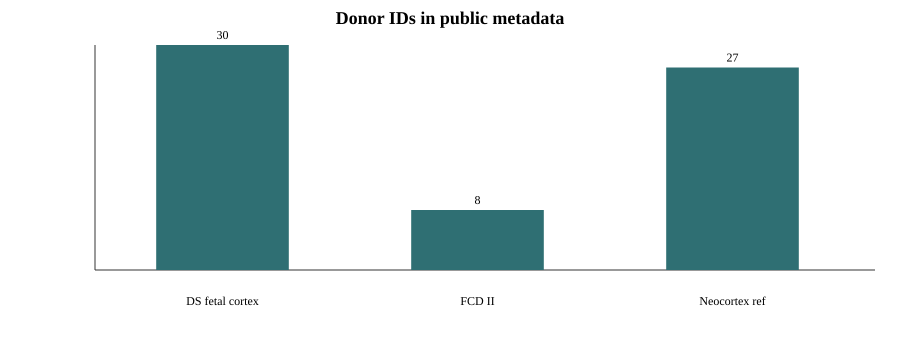

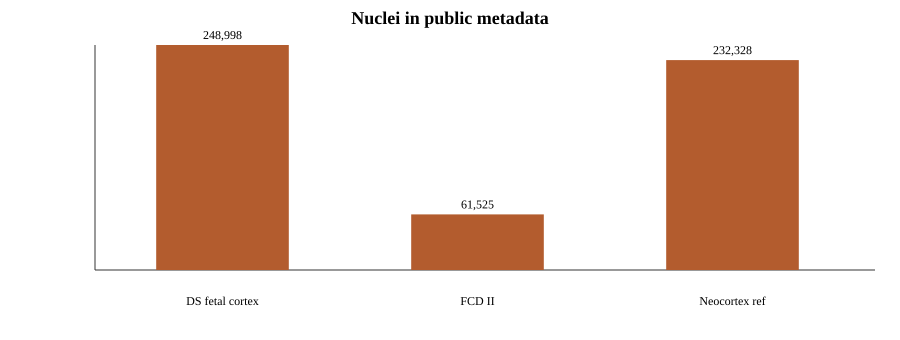

In [2]:
labels = [row['plot_label'] for row in datasets]
bar_svg(labels, [row['donors'] for row in datasets], 'Donor IDs in public metadata', '#2f6f73')
bar_svg(labels, [row['nuclei'] for row in datasets], 'Nuclei in public metadata', '#b35c2e')

## Asset Burden

This plot estimates download/storage burden from public metadata. Public file download and inspection can be used for access/compliance/file preflight; approval is required before disease-specific training or claims.

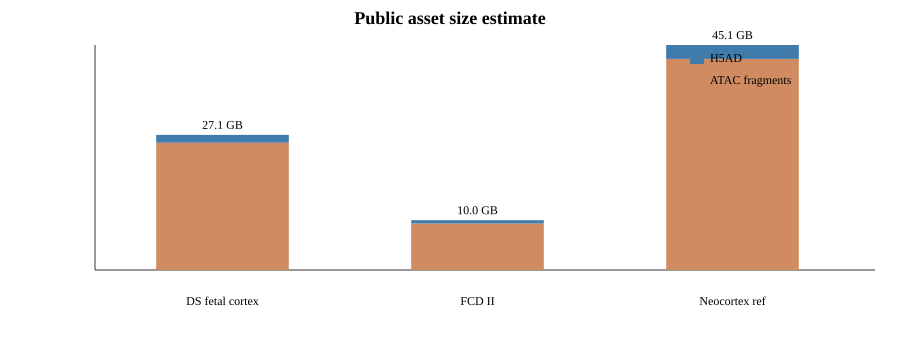

In [3]:
width, height = 900, 340
left, bottom, top = 95, 70, 45
chart_w = width - left - 40
chart_h = height - top - bottom
totals = [row['h5ad_gb'] + row['atac_fragment_gb'] for row in datasets]
max_total = max(totals) or 1
gap = chart_w / len(datasets)
bar_w = gap * 0.52
svg = [f'<svg viewBox="0 0 {width} {height}" width="100%" role="img">']
svg.append(f'<text x="{width/2}" y="24" text-anchor="middle" font-size="18" font-weight="600">Public asset size estimate</text>')
svg.append(f'<line x1="{left}" y1="{top}" x2="{left}" y2="{height-bottom}" stroke="#333"/>')
svg.append(f'<line x1="{left}" y1="{height-bottom}" x2="{width-25}" y2="{height-bottom}" stroke="#333"/>')
for i, row in enumerate(datasets):
    x = left + i * gap + gap * 0.24
    h_h5ad = chart_h * row['h5ad_gb'] / max_total
    h_atac = chart_h * row['atac_fragment_gb'] / max_total
    y_atac = height - bottom - h_atac
    y_h5ad = y_atac - h_h5ad
    svg.append(f'<rect x="{x:.1f}" y="{y_atac:.1f}" width="{bar_w:.1f}" height="{h_atac:.1f}" fill="#d08c60"/>')
    svg.append(f'<rect x="{x:.1f}" y="{y_h5ad:.1f}" width="{bar_w:.1f}" height="{h_h5ad:.1f}" fill="#3f7cac"/>')
    svg.append(f'<text x="{x + bar_w/2:.1f}" y="{max(38, y_h5ad-6):.1f}" text-anchor="middle" font-size="12">{row["h5ad_gb"] + row["atac_fragment_gb"]:.1f} GB</text>')
    svg.append(f'<text x="{x + bar_w/2:.1f}" y="{height-35}" text-anchor="middle" font-size="12">{escape(row["plot_label"])}</text>')
svg.append('<rect x="690" y="50" width="14" height="14" fill="#3f7cac"/><text x="710" y="62" font-size="12">H5AD</text>')
svg.append('<rect x="690" y="72" width="14" height="14" fill="#d08c60"/><text x="710" y="84" font-size="12">ATAC fragments</text>')
svg.append('</svg>')
show_html(''.join(svg))

## Preflight Criteria Heatmap

Scores: 2 = pass from public metadata, 1 = caution or must verify in file, 0 = fail. I treat these scores only as planning signals, not experimental results.

In [4]:
criteria_rows = [
    {
        'dataset': 'Down syndrome fetal cortex',
        '10x/multiome': 2,
        'donor IDs': 2,
        'disease labels': 2,
        'stage labels': 2,
        'donor count': 2,
        'ATAC fragments': 2,
        'target clarity': 1,
        'direction fit': 1,
    },
    {
        'dataset': 'FCD II',
        '10x/multiome': 2,
        'donor IDs': 2,
        'disease labels': 1,
        'stage labels': 1,
        'donor count': 1,
        'ATAC fragments': 2,
        'target clarity': 1,
        'direction fit': 2,
    },
    {
        'dataset': 'Developing neocortex reference',
        '10x/multiome': 2,
        'donor IDs': 2,
        'disease labels': 0,
        'stage labels': 2,
        'donor count': 2,
        'ATAC fragments': 2,
        'target clarity': 1,
        'direction fit': 1,
    },
]
criteria_cols = [key for key in criteria_rows[0].keys() if key != 'dataset']
colors = {0: '#f3d2c1', 1: '#fef3bd', 2: '#b7e4c7'}
html = ['<table><thead><tr><th>Dataset</th>']
html.extend(f'<th>{escape(col)}</th>' for col in criteria_cols)
html.append('</tr></thead><tbody>')
for row in criteria_rows:
    html.append(f'<tr><td><b>{escape(row["dataset"])}</b></td>')
    for col in criteria_cols:
        value = row[col]
        html.append(f'<td style="text-align:center;background:{colors[value]};font-weight:600">{value}</td>')
    html.append('</tr>')
html.append('</tbody></table>')
show_html(''.join(html))

Dataset,10x/multiome,donor IDs,disease labels,stage labels,donor count,ATAC fragments,target clarity,direction fit
Down syndrome fetal cortex,2,2,2,2,2,2,1,1
FCD II,2,2,1,1,1,2,1,2
Developing neocortex reference,2,2,0,2,2,2,1,1


## Decision Table

This table shows what I think each dataset is useful for, what risk blocks it, and what I would do next if you approve the direction.

In [5]:
decision_columns = [
    ('short_name', 'Dataset'),
    ('role', 'Role'),
    ('donors', 'Donors'),
    ('nuclei', 'Nuclei'),
    ('conditions', 'Condition labels'),
    ('h5ad_gb', 'H5AD GB'),
    ('atac_fragment_gb', 'ATAC fragments GB'),
    ('primary_strength', 'Primary strength'),
    ('main_risk', 'Main risk'),
    ('recommendation', 'Recommendation'),
]
show_html(html_table(datasets, decision_columns))

Dataset,Role,Donors,Nuclei,Condition labels,H5AD GB,ATAC fragments GB,Primary strength,Main risk,Recommendation
Down syndrome fetal cortex,Primary proposed preflight,30,248998,complete trisomy 21; normal,1.57,25.51,largest donor count among disease candidates; disease plus fetal-stage labels,fetal Down syndrome may be outside the psychiatric/developmental direction you prefer,I would preflight this first if you approve DS/fetal-development scope
FCD II,Disease backup,8,61525,isolated focal cortical dysplasia type II; control mapping needs file check,0.66,9.32,closer cortical lesion disease; smaller download burden,small donor count; control/lesion labels must be verified inside files,I would keep this as backup if DS scope is not preferred or storage/compute constraints dominate
Developing human neocortex reference,Reference and validation context,27,232328,normal/reference; no disease case-control label,2.78,42.32,strong donor count and broad developmental-stage coverage for normal cortex context,not a disease cohort; I would not use it as the primary disease paper dataset,"I would use this only as normal developmental reference or comparator, not as the primary disease dataset"


## Proposed Recommendation

I would use the **Down syndrome fetal cortex 10x Multiome** dataset first if you agree that DS/fetal cortical development fits the intended psychiatric/developmental direction. It has the best mix of disease/control labels, 30 donor IDs, paired RNA/ATAC public assets, and developmental-stage metadata.

I would keep **FCD II 10x Multiome** as the backup disease option. It is closer to focal cortical disease biology and has a smaller storage burden, but the donor count is weaker and the control/lesion target structure must be verified inside the files before I treat it as a reliable primary study.

I would use the **developing human neocortex snMultiome** dataset only as a normal developmental reference or comparator. It is useful for stage and regulatory context, but because it lacks a disease label, making it the primary dataset would weaken alignment with the current disease-focused MOM guidance.

I will not proceed to model training, biological interpretation, or result figures without approval and a passing file-level preflight. Public H5AD/ATAC download for access/compliance/file preflight does not require that approval.

In [6]:
proposal_rows = [
    {
        'rank': 1,
        'use': 'I would preflight Down syndrome fetal cortex first',
        'why': 'best current disease-plus-development candidate; 30 donors; paired RNA/ATAC assets; stage labels',
        'boundary': 'needs your approval because DS/fetal direction may differ from preferred psychiatric scope',
    },
    {
        'rank': 2,
        'use': 'I would keep FCD II as backup',
        'why': 'closer cortical disease and smaller compute burden',
        'boundary': 'small donor count; control mapping must be verified before target selection',
    },
    {
        'rank': 3,
        'use': 'I would use developing neocortex as reference only',
        'why': 'strong normal developmental context for regulatory/stage interpretation',
        'boundary': 'not disease-primary; use only as reference/comparator',
    },
]
show_html(html_table(proposal_rows, [('rank', 'Rank'), ('use', 'Use'), ('why', 'Why'), ('boundary', 'Boundary')]))

Rank,Use,Why,Boundary
1,I would preflight Down syndrome fetal cortex first,best current disease-plus-development candidate; 30 donors; paired RNA/ATAC assets; stage labels,needs your approval because DS/fetal direction may differ from preferred psychiatric scope
2,I would keep FCD II as backup,closer cortical disease and smaller compute burden,small donor count; control mapping must be verified before target selection
3,I would use developing neocortex as reference only,strong normal developmental context for regulatory/stage interpretation,not disease-primary; use only as reference/comparator


## Required Preflight Checklist

If you approve the first preflight, I would check only the minimum file-level feasibility items first:

1. Confirm H5AD has usable obs fields for donor_id, condition, sample, developmental week/stage, sex, and batch.
2. Confirm ATAC fragments or peak matrix can be linked to RNA barcodes.
3. Confirm donor-held-out split has enough case/control or stage-stratified donors in train, validation, and test.
4. Confirm no target is derived circularly from features used for training.
5. Confirm train-only feature selection and transforms can be implemented.
6. Confirm external validation resources are separate from training and target construction.

If any of these checks fails, I would stop and report the failure rather than forcing the dataset into the study.

## Source Links

- Down syndrome fetal cortex CELLxGENE: https://cellxgene.cziscience.com/collections/0e9fd1d3-ef4c-47c6-a2e4-ef4bfadf7c79
- Down syndrome DOI: https://doi.org/10.1038/s41591-026-04211-1
- Down syndrome GEO: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE305153
- FCD II CELLxGENE: https://cellxgene.cziscience.com/collections/9e4e8f1d-d905-4d4f-b343-84889d0f9ffe
- FCD II DOI: https://doi.org/10.1016/j.isci.2024.111337
- FCD II GEO: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE268807
- Developing human neocortex CELLxGENE: https://cellxgene.cziscience.com/collections/ad2149fc-19c5-41de-8cfe-44710fbada73
- Developing human neocortex DOI: https://doi.org/10.1038/s41586-024-08351-7
- Developing human neocortex NeMO asset link: https://assets.nemoarchive.org/dat-oiif74w